# Financial Equations

There are a handful of useful equations to know when analyzing a case. I'll look reference a quick [weblink](https://www.freshbooks.com/hub/finance/finance-equations) that outlines some key equations - *it is important to remember the impact human capital will have on sales, your company culture, and the results you are able to deliver with your team.*

## Accounting Equation
The accounting equation, or rather *the balance sheet* equation is pretty important and intentionally simple:

**Total Assets = Liabilities + Equity**

*Assets*: Your assets are everything your company owns. This includes property, cash, inventory and any equipment.

*Liabilities*: These are any obligations that you must pay. It may include lease payments, debt or account fees.

*Equity*: Your equity is the portion of the company that belongs to you. If shareholders own the majority of the company, then the stockholders’ equity falls into this category.


In [1]:
def balance_accounting_eq():
    # quick maths: 5000, 15000, 20000
    equity = float(input("Enter equity: ")) 
    assets = float(input("Enter assets: "))
    liabilities = float(input("Enter liabilities: "))

    if assets == liabilities + equity:
        print("Accounting equation is balanced!")

    else :
        print("Accounting error :/")

In [2]:
balance_accounting_eq()

Enter equity:  500
Enter assets:  1500
Enter liabilities:  2000


Accounting error :/


In [3]:
balance_accounting_eq()

Enter equity:  500
Enter assets:  2000
Enter liabilities:  1500


Accounting equation is balanced!


## Cash Flow Equation

I'll reference an article written by [Ariel Herrera](https://levelup.gitconnected.com/how-to-calculate-cash-flow-and-visualize-it-in-python-9305c4cb190f) for an excellent, brief overview of how to analyze cash flows. Calculating cash flow is essential to any business. Knowing your cash flow will create more opportunity to reinvest profits from an investment into another investment - kind of like pulling off a parlay.

Knowing your cash flow also creates safety, you can set various risk measures to develop your investing strategy. Cash flow will let you know if you might want to consider playing it safer at some points.  

**Income - Expenses = Cash Flow**

*Income:* Your income is any money that’s coming into the business. This could be through sales, investments or gifts.

*Expenses:* Your expenses are any money that is leaving the business. This could include rent, buying raw materials or wages.

*Cash Flow:* Cash Flow is defined as what’s left after you’ve included income and expenses. If you have a positive cash flow then you are running a profitable business, if it is negative then you are losing money.

In [4]:
import plotly.graph_objects as go
import pandas as pd

In [5]:
df = pd.read_csv('https://raw.githubusercontent.com/analyticsariel/public-data/main/cash_flow_data.csv')
df.head()

,property_address,rent,additional_income,principal_and_interest,taxes,insurance,property_management,cap_ex,vacancy,utilities,additional_expenses
0,"123 Main St, Tampa, FL 33603",2600,50,1159,528,80,234,130,208,50,75


In [6]:
# assign variables to values in table
property_address = df['property_address'].iloc[0]
rent = df['rent'].iloc[0]
additional_income = df['additional_income'].iloc[0]
principal_and_interest = df['principal_and_interest'].iloc[0]
taxes = df['taxes'].iloc[0]
insurance = df['insurance'].iloc[0]
property_management = df['property_management'].iloc[0]
cap_ex = df['cap_ex'].iloc[0]
vacancy = df['vacancy'].iloc[0]
utilities = df['utilities'].iloc[0]
additional_expenses = df['additional_expenses'].iloc[0]

In [7]:
# summary variables
total_income = rent + additional_income
fixed_expense = principal_and_interest + taxes + insurance
variable_expense = property_management + cap_ex + vacancy + utilities + additional_expenses
total_expense = fixed_expense + variable_expense

In [8]:
# create list of labels for the chart
label_list = [ "Income",
               "Rent", 
               "Additional Income",
               "Expense", 
               "Fixed",
               "Variable",
               "Principal & Interest",
               "Taxes",
               "Insurance", 
               "Property Management", 
               "CapEx",
               "Vacancy",
               "Utilities",
               "Additional Expenses",
               ]

# append an index number to each element in the list
label_dict = {}
for i in range(len(label_list)):
  label_dict[label_list[i]] = i

In [9]:
# create sub list for each node -> target -> value
sankey_list = [
  # income
  ["Income", "Rent", rent], 
  ["Income", "Additional Income", additional_income], 
  # expenses [fixed]
  ["Expense", "Fixed", fixed_expense], 
  ["Fixed", "Principal & Interest", principal_and_interest], 
  ["Fixed", "Taxes", taxes], 
  ["Fixed", "Insurance", insurance],
  # expenses [variable]
  ["Expense", "Variable", variable_expense], 
  ["Variable", "Property Management", property_management], 
  ["Variable", "CapEx", cap_ex], 
  ["Variable", "Vacancy", vacancy], 
  ["Variable", "Utilities", utilities], 
  ["Variable", "Additional Expenses", additional_expenses],
]

In [10]:
# create sublists from the sankey list
source_list = [label_dict[x[0]] for x in sankey_list]
target_list = [label_dict[x[1]] for x in sankey_list]
value_list = [x[2] for x in sankey_list]

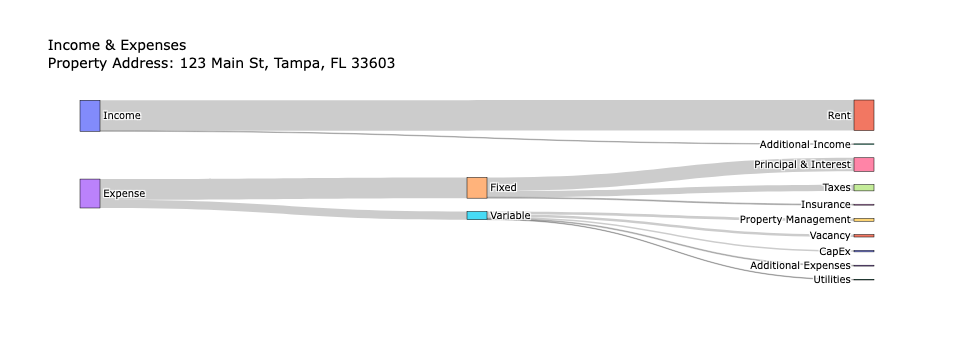

In [17]:
# create figure
fig = go.Figure(data=[go.Sankey(
    # nodes
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label_list, # cash flow parameters
      hovertemplate='%{label} has total value $%{value}',
    ),
    # links
    link = dict(
      source = source_list, # start node
      target = target_list, # end node
      value = value_list # value of end node
  ))])

fig.update_layout(
    hovermode = 'x',
    title="Income & Expenses<br>Property Address: {}".format(property_address),
    # optional for black background
    font=dict(size = 10, color = 'black'),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

## Break-Even Equation

When starting a business, the first goal you would want to achieve is to break even. This means that you are neither making a profit nor a loss.

**Break Even Quantity = Fixed Costs / (Sales Price per Unit – Variable Cost Per Unit)**

*Fixed Costs* are costs that do not change with varying output (e.g., salary, rent, building machinery).

*Sales Price per Unit* is the selling price (unit selling price) per unit.

*Variable Cost per Unit* is the variable costs incurred to create a unit.

In [12]:
def break_even(fixed_costs, variable_costs, unit_price):
    return abs(fixed_costs / (variable_costs - unit_price))

In [13]:
"""
Ex: Colin is the managerial accountant in charge of Company A, which sells water bottles. He previously 
determined that the fixed costs of Company A consist of property taxes, a lease, and executive salaries, 
which add up to 100,000. The variable cost associated with producing one water bottle is 2 per unit. The water 
bottle is sold at a premium price of 12. Determine the break even point of Company A’s premium water bottle.
"""
fixed_costs = 100000
variable_costs = 2
unit_price = 12

break_even(fixed_costs, variable_costs, unit_price)

10000.0

Therefore, given the fixed costs, variable costs, and selling price of the water bottles, Company A would need to sell 10,000 units of water bottles to break even. We can visualize this with an exmaple [CVP](https://corporatefinanceinstitute.com/resources/knowledge/modeling/break-even-analysis/) graph.

In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.__version__

'3.5.1'

Text(0.5, 1.0, 'Simple CVP Graph')

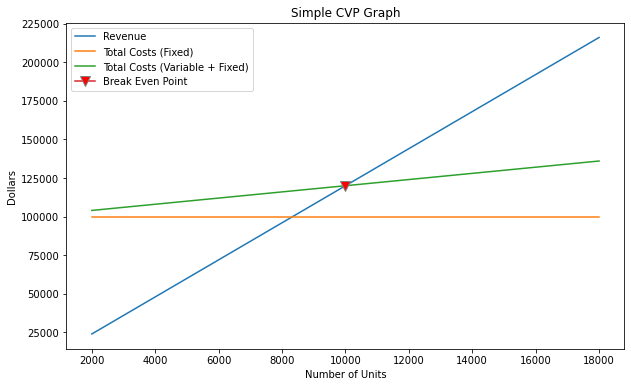

In [15]:
plt.figure(figsize=(10, 6))

# plot revenue
x = np.linspace(2000, 18000)
y = unit_price * x
plt.plot(x, y, label='Revenue')

# plot fixed costs
x = np.linspace(2000, 18000)
y = 0*x + fixed_costs
plt.plot(x, y, label='Total Costs (Fixed)')

# plot total costs
x = np.linspace(2000, 18000)
y = 2*x + fixed_costs
plt.plot(x, y, label='Total Costs (Variable + Fixed)')

# plot the break-even point
x = [break_even(fixed_costs, variable_costs, unit_price)]
y = [break_even(fixed_costs, variable_costs, unit_price)*unit_price]
plt.plot(x, y, marker="v", markersize=10, markeredgecolor="grey", markerfacecolor="red", label='Break Even Point')

# make our graph worth looking at
plt.legend(loc=0)
plt.xlabel('Number of Units')
plt.ylabel('Dollars')
plt.title("Simple CVP Graph")

## Simple Interest Equation
Simple interest, otherwise known as principal interest, applies when you are looking to find out the interest being charged on a business loan.

**Interest = Principal Amount x Rate x Time**

*Interest:* This is the interest rate of the loan.

*Principal Amount:* The amount you have loaned.

*Rate:* The rate of interest charged per year as a decimal number.

*Time:* The number of years the money is borrowed or invested.

In [18]:
def simple_interest(principal, rate, time):
    return (principal*time*rate)/100

In [20]:
principal = float(input('Enter the principle amount: '))
rate = float(input('Enter the rate: '))
time = float(input('Enter the time (years): '))
print("Simple interest is:", '${}'.format(simple_interest(principal, rate, time)))

Enter the principle amount:  5000
Enter the rate:  4
Enter the time (years):  2


Simple interest is: $400.0


## Compound Interest Equation

Your compound interest is the addition of interest to the principal sum of a loan. Basically, it is your interest. This one is slightly more complicated.

**A = P (1 + r/n) nt**

*A:* This is the amount earned after your interest.

*P:* The principal amount of the loan.

*r:* The annual rate of interest as a decimal.

*n:* The number of times per year that the interest is compounded.

*t:* How many years the money is borrowed for.

In [32]:
def compound_interest(principle, rate, pers, years):
    return principal*(pow((1+rate/100/pers), pers*years))

In [33]:
p = int(input("Enter starting principle please:"))
n = int(input("Enter number of compounding periods per year:"))
r = float(input("Enter annual interest rate (1-100):"))
t = int(input("Enter the amount of years:"))
print("Compounding interest is:", '${}'.format(compound_interest(p, n, r, t)))

Enter starting principle please: 5000
Enter number of compounding periods per year: 1
Enter annual interest rate (1-100): 6
Enter the amount of years: 5


Compounding interest is: $5256.136714667014


## Profit Margin Equation
Knowing your profit margins is key. Too high and your product most likely won’t be good value, too low and you won’t be profitable.

**Profit Margin = Net Income ÷ Sales**

*Profit Margin:* This shows how much money you make above the costs.

*Net Income:* The total amount of money your business has made once you’ve removed its expenses.

*Sales:* The money you generate from any business activities.

# Conclusions

Good accountants and good software both matter and go hand in hand. Data powers the modern business and it using data to inform busines decisions is crucial in today's gig economy.